<a href="https://colab.research.google.com/github/dinusariehewage-coder/ET3112-/blob/main/Q7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Normalized SSD (Nearest Neighbor): 0.007585662
Normalized SSD (Bilinear): 0.0068086446


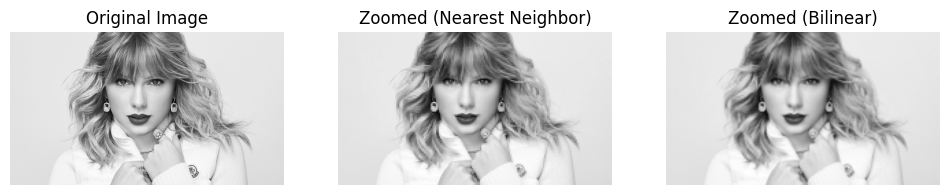

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# Zoom Function

def zoom_image(img, scale, method='nearest'):
    h, w = img.shape
    new_h = int(h * scale)
    new_w = int(w * scale)

    zoomed = np.zeros((new_h, new_w), dtype=np.float32)

    for y in range(new_h):
        for x in range(new_w):
            src_x = x / scale
            src_y = y / scale

            if method == 'nearest':
                sx = int(round(src_x))
                sy = int(round(src_y))
                sx = min(sx, w - 1)
                sy = min(sy, h - 1)
                zoomed[y, x] = img[sy, sx]

            elif method == 'bilinear':
                x0 = int(np.floor(src_x))
                y0 = int(np.floor(src_y))
                x1 = min(x0 + 1, w - 1)
                y1 = min(y0 + 1, h - 1)

                dx = src_x - x0
                dy = src_y - y0

                p1 = img[y0, x0]
                p2 = img[y0, x1]
                p3 = img[y1, x0]
                p4 = img[y1, x1]

                zoomed[y, x] = (
                    p1 * (1 - dx) * (1 - dy) +
                    p2 * dx * (1 - dy) +
                    p3 * (1 - dx) * dy +
                    p4 * dx * dy
                )

    return zoomed



# Normalized SSD Function

def normalized_ssd(img1, img2):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    return np.sum((img1 - img2) ** 2) / np.sum(img1 ** 2)



# LOAD IMAGES  (EDIT THESE PATHS ONLY)

original_path = '/Q7/taylor.jpg'
small_path = '/Q7/taylor_small.jpg'

original = cv.imread(original_path, cv.IMREAD_GRAYSCALE)
small = cv.imread(small_path, cv.IMREAD_GRAYSCALE)

if original is None or small is None:
    raise FileNotFoundError("Check image paths!")


# Compute Scale Factor

scale = original.shape[0] / small.shape[0]


# Zoom Images

zoom_nn = zoom_image(small, scale, method='nearest')
zoom_bl = zoom_image(small, scale, method='bilinear')


# Compute SSD

ssd_nn = normalized_ssd(original, zoom_nn)
ssd_bl = normalized_ssd(original, zoom_bl)

print("Normalized SSD (Nearest Neighbor):", ssd_nn)
print("Normalized SSD (Bilinear):", ssd_bl)


# Display Results

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(zoom_nn, cmap='gray')
plt.title('Zoomed (Nearest Neighbor)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(zoom_bl, cmap='gray')
plt.title('Zoomed (Bilinear)')
plt.axis('off')

plt.show()
